# 特徴量エンジニアリングとLasso回帰

`feature_engineering_dataset.csv` を使い、特徴量エンジニアリングを行ったあとにLasso回帰で予測します。

第3回の `lasso_medv_analysis.ipynb` から最小限の変更で作成しています。

【Python セミナー 第4回】  
特徴量エンジニアリングで作成した説明変数を使い、Lasso回帰を実行する。

In [1]:
# 必要なライブラリを読み込む。
# numpy は、数値計算や配列計算に使うライブラリ。
# ここでは RMSE を計算するときの平方根や、グラフ用の数値列を作るために使う。
import numpy as np
# pandas は、CSVの読み込みや表形式データの前処理に使うライブラリ。
# DataFrame という表形式のデータ構造を使って、列の選択や欠損値補完を行う。
import pandas as pd
# matplotlib.pyplot は、グラフを描くためのライブラリ。
# 今回は、実測値と予測値の散布図や、Lasso回帰の係数グラフを描く。
import matplotlib.pyplot as plt

# train_test_split は、データを学習用データとテスト用データに分けるために使う。
from sklearn.model_selection import train_test_split
# mean_squared_error, mean_absolute_error, r2_score は、予測精度を数値で評価するための指標。
# MSE/RMSE, MAE, R2 を計算して、モデルの良し悪しを確認する。
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# LassoCV は、Lasso回帰の正則化の強さ alpha を交差検証で自動選択するモデル。
# Lasso回帰は、重要でない特徴量の係数を0にしやすいという特徴がある。
from sklearn.linear_model import LassoCV


In [2]:
# 予測結果を評価し、実測値と予測値の散布図を描く関数を定義する。
# 同じ評価処理を学習データとテストデータの両方に使うため、関数としてまとめておく。
# train_targets: 学習データの実測値。
# train_predictions: 学習データに対する予測値。
# test_targets: テストデータの実測値。
# test_predictions: テストデータに対する予測値。
# model_name: グラフタイトルや表示文に使うモデル名。
# target_name: 軸ラベルに使う目的変数名。
def pred_plot(train_targets, train_predictions, test_targets, test_predictions, model_name, target_name):
    # 学習データに対する評価指標を計算する。
    # MSE は、誤差を2乗して平均した値。大きな誤差を強く評価する。
    train_mse = mean_squared_error(train_targets, train_predictions)
    # MAE は、誤差の絶対値を平均した値。実際の誤差の大きさを直感的に見やすい。
    train_mae = mean_absolute_error(train_targets, train_predictions)
    # R2 は決定係数。1に近いほど、実測値のばらつきをよく説明できている。
    train_r2 = r2_score(train_targets, train_predictions)
    # RMSE は MSE の平方根。目的変数と同じ単位で誤差を確認できる。
    train_rmse = np.sqrt(train_mse)

    # テストデータに対する評価指標を計算する。
    # テストデータの性能は、未知データに対する予測性能の目安になる。
    test_mse = mean_squared_error(test_targets, test_predictions)
    test_mae = mean_absolute_error(test_targets, test_predictions)
    test_r2 = r2_score(test_targets, test_predictions)
    test_rmse = np.sqrt(test_mse)

    # グラフ描画で扱いやすいように、Series や DataFrame を1次元の NumPy 配列へ変換する。
    # ravel() は、縦ベクトルのような形のデータを1列の配列に平らにする処理。
    train_targets_array = np.asarray(train_targets).ravel()
    train_predictions_array = np.asarray(train_predictions).ravel()
    test_targets_array = np.asarray(test_targets).ravel()
    test_predictions_array = np.asarray(test_predictions).ravel()

    # 学習データの評価結果を表示する。
    # 学習データの結果が良すぎてテストデータの結果が悪い場合は、過学習の可能性がある。
    print(f'\n{model_name} Training Set Performance:')
    print(f'Samples: {len(train_predictions)} | RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}')

    # テストデータの評価結果を表示する。
    # こちらの値を重視して、未知データに対してどれくらい予測できるかを確認する。
    print(f'\n{model_name} Test Set Performance:')
    print(f'Samples: {len(test_predictions)} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}')

    # 1行2列のグラフ領域を作る。
    # 左に学習データ、右にテストデータの散布図を描く。
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # 学習データについて、横軸を実測値、縦軸を予測値にした散布図を描く。
    # 点が対角線に近いほど、予測値が実測値に近いことを意味する。
    ax1.scatter(train_targets_array, train_predictions_array, alpha=0.6, color='red', s=20)
    # 実測値と予測値の両方を含む範囲を求め、y=x の基準線を描けるようにする。
    train_min = min(train_targets_array.min(), train_predictions_array.min())
    train_max = max(train_targets_array.max(), train_predictions_array.max())
    # train_min から train_max までの連続した値を作る。
    train_range = np.linspace(train_min, train_max)
    # y=x の基準線を黒い破線で描く。
    # この線の上に点が乗っていれば、実測値と予測値が完全に一致している。
    ax1.plot(train_range, train_range, 'k--', lw=2)
    # 軸ラベルとタイトルを設定する。
    ax1.set_xlabel(f'Actual {target_name}')
    ax1.set_ylabel(f'Predicted {target_name}')
    ax1.set_title(f'{model_name} Training Set (n={len(train_predictions)})\nRMSE: {train_rmse:.3f} | MAE: {train_mae:.3f} | R2: {train_r2:.3f}')
    # グリッドを薄く表示して、点の位置を読み取りやすくする。
    ax1.grid(True, alpha=0.3)
    # 縦軸と横軸の縮尺をそろえ、対角線からのずれを視覚的に比較しやすくする。
    ax1.set_aspect('equal', adjustable='box')

    # テストデータについても、学習データと同じ形式で散布図を描く。
    ax2.scatter(test_targets_array, test_predictions_array, alpha=0.6, color='blue', s=20)
    # テストデータ用の表示範囲を、実測値と予測値の両方から決める。
    test_min = min(test_targets_array.min(), test_predictions_array.min())
    test_max = max(test_targets_array.max(), test_predictions_array.max())
    test_range = np.linspace(test_min, test_max)
    # テストデータにも y=x の基準線を描く。
    ax2.plot(test_range, test_range, 'k--', lw=2)
    ax2.set_xlabel(f'Actual {target_name}')
    ax2.set_ylabel(f'Predicted {target_name}')
    ax2.set_title(f'{model_name} Test Set (n={len(test_predictions)})\nRMSE: {test_rmse:.3f} | MAE: {test_mae:.3f} | R2: {test_r2:.3f}')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

    # ラベルやタイトルが重ならないように、グラフの余白を自動調整する。
    plt.tight_layout()
    # ノートブック上にグラフを表示する。
    plt.show()


In [3]:
# Lasso回帰で得られた係数を可視化する関数。
# Lasso回帰では、予測にあまり効いていない特徴量の係数が0になりやすい。
# そのため、係数を見ることで、どの特徴量がモデルに使われたかを確認できる。
# model: 学習済みの LassoCV モデル。
# X: 学習に使った説明変数。列名を特徴量名として使う。
# model_name: グラフタイトルに表示するモデル名。
def lasso_coefficients(model, X, model_name):
    # 学習済みモデルから各特徴量の係数を取り出す。
    # 係数が正なら目的変数を大きくする方向、負なら小さくする方向に働く。
    coefficients = model.coef_
    # X の列名を特徴量名として使う。
    # 係数の並び順と X.columns の並び順は対応している。
    feature_names = X.columns

    # 特徴量名と係数を1つの表にまとめる。
    coefficient_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    # 係数の絶対値を計算する。
    # 正負に関係なく、影響の大きさで並べ替えるために使う。
    coefficient_df['AbsCoefficient'] = coefficient_df['Coefficient'].abs()
    # 影響が大きい特徴量から順に見られるよう、係数の絶対値で降順に並べ替える。
    coefficient_df = coefficient_df.sort_values(by='AbsCoefficient', ascending=False)

    # 係数の表をノートブック上に表示する。
    # AbsCoefficient は並べ替え用なので、表示は Feature と Coefficient のみにする。
    display(coefficient_df[['Feature', 'Coefficient']])

    # 係数が0ではない特徴量だけを取り出す。
    # Lassoでは、係数が0の特徴量はモデルから実質的に使われていないと考えられる。
    selected_df = coefficient_df[coefficient_df['AbsCoefficient'] > 0]

    # 係数が0ではない特徴量を横棒グラフで表示する。
    # 特徴量数が多い場合でも読めるように、特徴量数に応じてグラフの高さを変える。
    plt.figure(figsize=(10, max(5, selected_df.shape[0] * 0.3)))
    # 横棒グラフでは、縦軸に特徴量名、横軸に係数を置く。
    plt.barh(selected_df['Feature'], selected_df['Coefficient'])
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.title(f'Coefficients in {model_name}')
    # 影響が大きい特徴量を上から表示するため、縦軸の並びを反転する。
    plt.gca().invert_yaxis()
    # 値を読み取りやすくするため、薄いグリッドを表示する。
    plt.grid(True, alpha=0.3)
    plt.show()

    # 最後に、Lasso回帰で実際に使われた特徴量数を表示する。
    # 分母は特徴量エンジニアリング後の全特徴量数。
    print(f'使用された特徴量数: {selected_df.shape[0]} / {X.shape[1]}')


In [4]:
# CSV ファイルを読み込む。
# pd.read_csv は、CSVファイルを pandas の DataFrame として読み込む関数。
# ファイル名だけを書いているので、このノートブックと同じフォルダにあるCSVを読み込む。
# feature_engineering_dataset.csv には、説明変数 x1〜x4 と目的変数 y が入っている。
df = pd.read_csv('feature_engineering_dataset.csv')

# データを確認する。
# ノートブックでは、変数名だけを最後に書くと、そのDataFrameの中身が表として表示される。
# 列名、行数、値の雰囲気を見て、読み込みが正しくできているか確認する。
df


,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840
...,...,...,...,...,...
995,-4.084179,1.569552,3.652958,-0.578930,6.807607
996,4.173136,4.566146,-3.427268,-1.655988,9.779621
997,-3.631814,-4.310420,-1.902121,-1.054277,5.926408
998,4.502374,-4.429453,-2.099545,0.299406,11.194125


In [5]:
# モデル学習に使わない列を削除する。
# id や smiles などの識別子列がある場合は、ここに列名を追加する。
# 識別子列は、各サンプルを区別するための名前や番号であり、物性や寿命の原因を表す特徴量ではないことが多い。
# そのような列を学習に使うと、モデルが本質的でない情報を覚えてしまう可能性がある。
# 今回のサンプルデータには削除すべき列がないため、空のリストにしている。
drop_list = []

# drop_list に入っている列を df から削除し、学習用のデータ df_clean を作る。
# drop_list が空の場合は、元の df と同じ列を持つDataFrameになる。
df_clean = df.drop(columns=drop_list)
# 削除後のデータを表示し、必要な列が残っているか確認する。
df_clean


,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840
...,...,...,...,...,...
995,-4.084179,1.569552,3.652958,-0.578930,6.807607
996,4.173136,4.566146,-3.427268,-1.655988,9.779621
997,-3.631814,-4.310420,-1.902121,-1.054277,5.926408
998,4.502374,-4.429453,-2.099545,0.299406,11.194125


In [6]:
# 予測したい列を目的変数として指定する。
# 目的変数とは、モデルに予測させたい値のこと。
# 今回のサンプルデータでは y が目的変数だが、別のデータセットでも使えるように候補名を並べておく。
# データセットの列名が異なる場合は、この target_candidates のリストに列名を追加する。
target_candidates = ['lifespan', 'Lifespan', 'material_lifespan', 'Material_Lifespan', 'target', 'y']
# target_candidates の左から順に、df_clean に存在する列名を探す。
# どの候補も見つからない場合は、データフレームの最後の列を目的変数として使う。
target = next((column for column in target_candidates if column in df_clean.columns), df_clean.columns[-1])

# どの列が目的変数として選ばれたかを表示する。
# 想定と違う列が表示された場合は、target_candidates を見直す。
print(f'目的変数: {target}')

# y には、予測したい目的変数だけを入れる。
y = df_clean[target]
# x には、モデルの入力として使う説明変数を入れる。
# 目的変数を説明変数に含めると、答えを見ながら学習するデータリークになるため削除する。
x = df_clean.drop(columns=[target])

# 説明変数を、数値列とカテゴリ列に分ける。
# 数値列はそのまま計算に使える列で、カテゴリ列は文字列やラベルのような列。
# 後で、数値列には多項式特徴量を作り、カテゴリ列にはダミー変数化を行う。
# select_dtypes(include='number') で、int型やfloat型などの数値列だけを選ぶ。
numeric_columns = x.select_dtypes(include='number').columns
# select_dtypes(exclude='number') で、数値列以外、つまり文字列などのカテゴリ列を選ぶ。
categorical_columns = x.select_dtypes(exclude='number').columns

# 欠損値を補完する。
# 欠損値が残っていると特徴量計算や LassoCV でエラーになるため、先に埋めておく。
# 数値列は外れ値の影響を受けにくい中央値で補完する。
# x から数値列だけを取り出す。
# copy() を付けることで、元のDataFrameを直接変更してしまうことを避ける。
x_numeric = x[numeric_columns].copy()
# 各数値列の中央値を計算し、欠損値 NaN をその中央値で埋める。
x_numeric = x_numeric.fillna(x_numeric.median())

# カテゴリ列は、各列で最も多く出てくる値、つまり最頻値で補完する。
# x からカテゴリ列だけを取り出す。
x_categorical = x[categorical_columns].copy()
# カテゴリ列は列ごとに最頻値が異なるため、for文で1列ずつ処理する。
for column in x_categorical.columns:
    # mode()[0] は、その列で最も頻繁に出現する値を1つ取り出す処理。
    # 同率の最頻値が複数ある場合は、そのうち先頭の値を使う。
    x_categorical[column] = x_categorical[column].fillna(x_categorical[column].mode()[0])

# 特徴量エンジニアリング。
# ヒントに合わせて、元の数値特徴量に加えて各特徴量の2乗項と3乗項を作る。
# 例: x1 から x1^2 と x1^3、x2 から x2^2 と x2^3 を追加する。
# Lasso回帰は不要な特徴量の係数を0にしやすいため、追加した特徴量の中から重要なものを選ばせる。
x_numeric_engineered = x_numeric.copy()
# 数値列を1列ずつ取り出し、それぞれの2乗と3乗を新しい列として追加する。
for column in numeric_columns:
    x_numeric_engineered[f'{column}^2'] = x_numeric[column] ** 2
    x_numeric_engineered[f'{column}^3'] = x_numeric[column] ** 3

# カテゴリ列がある場合は、ダミー変数に変換する。
# ダミー変数化とは、文字列カテゴリを0/1の数値列に変換する処理。
# drop_first=True により、カテゴリのうち1つを基準として削除し、列同士の重複を減らす。
# 今回のサンプルデータのようにカテゴリ列が1つもない場合、pd.get_dummies に空のDataFrameを渡すとエラーになる。
# そのため、カテゴリ列がある場合だけ pd.get_dummies を実行する。
# len(categorical_columns) は、カテゴリ列の数を表す。
# 0より大きい場合だけ、カテゴリ列が存在すると判断する。
if len(categorical_columns) > 0:
    x_categorical_encoded = pd.get_dummies(x_categorical, drop_first=True, dtype=float)
else:
    # カテゴリ列がない場合は、行数とindexだけを合わせた空のDataFrameを用意する。
    # これにより、後の pd.concat で数値特徴量だけを問題なく結合できる。
    x_categorical_encoded = pd.DataFrame(index=x.index)

# 数値の特徴量エンジニアリング結果とカテゴリのダミー変数を結合する。
# axis=1 は、横方向、つまり列を追加する方向に結合するという意味。
x = pd.concat([x_numeric_engineered, x_categorical_encoded], axis=1)

# 元の説明変数数と、特徴量エンジニアリング後の説明変数数を確認する。
# 多項式特徴量を追加すると、説明変数の数は元より多くなる。
print(f'元の説明変数数: {numeric_columns.shape[0] + categorical_columns.shape[0]}')
print(f'特徴量エンジニアリング後の説明変数数: {x.shape[1]}')
x.head()


目的変数: y
元の説明変数数: 4
特徴量エンジニアリング後の説明変数数: 12


,x1,x2,x3,x4,x1^2,x1^3,x2^2,x2^3,x3^2,x3^3,x4^2,x4^3
0,-1.254599,-3.148671,-2.382943,1.727030,1.574018,-1.974761,9.914127,-31.216322,5.678418,-13.531348,2.982632,5.151095
1,4.507143,0.419009,-2.530212,2.966814,20.314339,91.559630,0.175569,0.073565,6.401973,-16.198348,8.801985,26.113853
2,2.319939,3.729458,4.062546,-2.495321,5.382119,12.486190,13.908860,51.872513,16.504278,67.049387,6.226627,-15.537433
3,0.986585,2.322249,-2.504538,1.248741,0.973350,0.960292,5.392840,12.523516,6.272711,-15.710242,1.559354,1.947229
4,-3.439814,3.065611,-2.280503,0.717460,11.832318,-40.700967,9.397974,28.810536,5.200693,-11.860194,0.514749,0.369311


In [7]:
# データをトレーニングセットとテストセットに分割する。
# トレーニングセットはモデルを学習するためのデータ。
# テストセットは、学習に使っていないデータで予測性能を確認するためのデータ。
# test_size=0.20 は、全データの20%をテストデータにするという意味。
# shuffle=True は、分割前にデータの順番をランダムに並べ替える設定。
# random_state=42 は、乱数の種を固定して、毎回同じ分割結果になるようにする設定。
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42)

# 目的変数 y_train を標準化する。
# 標準化とは、平均が0、標準偏差が1になるように値を変換する処理。
# Lasso回帰では正則化を使うため、スケールの違いによる影響を小さくする目的で標準化する。
# ここでは、学習データ y_train の平均と標準偏差を使って変換する。
auto_y_train = (y_train - y_train.mean()) / y_train.std()

# 説明変数 X_train を標準化する。
# 各特徴量の平均を計算する。
# 後でテストデータを同じ基準で標準化するため、この平均を保存しておく。
X_train_mean = X_train.mean()
# 各特徴量の標準偏差を計算する。
# 標準偏差が0の列は、すべて同じ値で割り算ができないため、replace(0, 1) で1に置き換える。
X_train_std = X_train.std().replace(0, 1)
# 学習データを、学習データ自身の平均と標準偏差で標準化する。
auto_X_train = (X_train - X_train_mean) / X_train_std

# テストデータは、トレーニングデータの平均と標準偏差を使って標準化する。
# テストデータ自身の平均や標準偏差を使うと、テストデータの情報を前処理に使ってしまう。
# これはデータリークになるため、必ず学習データから計算した平均と標準偏差を使う。
auto_X_test = (X_test - X_train_mean) / X_train_std

# 分析対象の目的変数名、説明変数の数、データ数を表示する。
# ここで想定と違う数が出た場合は、前処理や目的変数の選択を確認する。
print(f'目的変数:{target},説明変数:{x.shape[1]},データ数:{x.shape[0]}')
# 学習データとテストデータのサンプル数を表示する。
# test_size=0.20 の設定どおり、おおよそ8:2に分かれているか確認する。
print(f'トレーニングセット:{X_train.shape[0]},テストセット:{X_test.shape[0]}')


目的変数:y,説明変数:12,データ数:1000
トレーニングセット:800,テストセット:200


最適な alpha: 0.005960

Lasso with Squared and Cubed Features Training Set Performance:
Samples: 800 | RMSE: 2.0378 | MAE: 1.6373 | R2: 0.9595

Lasso with Squared and Cubed Features Test Set Performance:
Samples: 200 | RMSE: 2.0588 | MAE: 1.6318 | R2: 0.9601


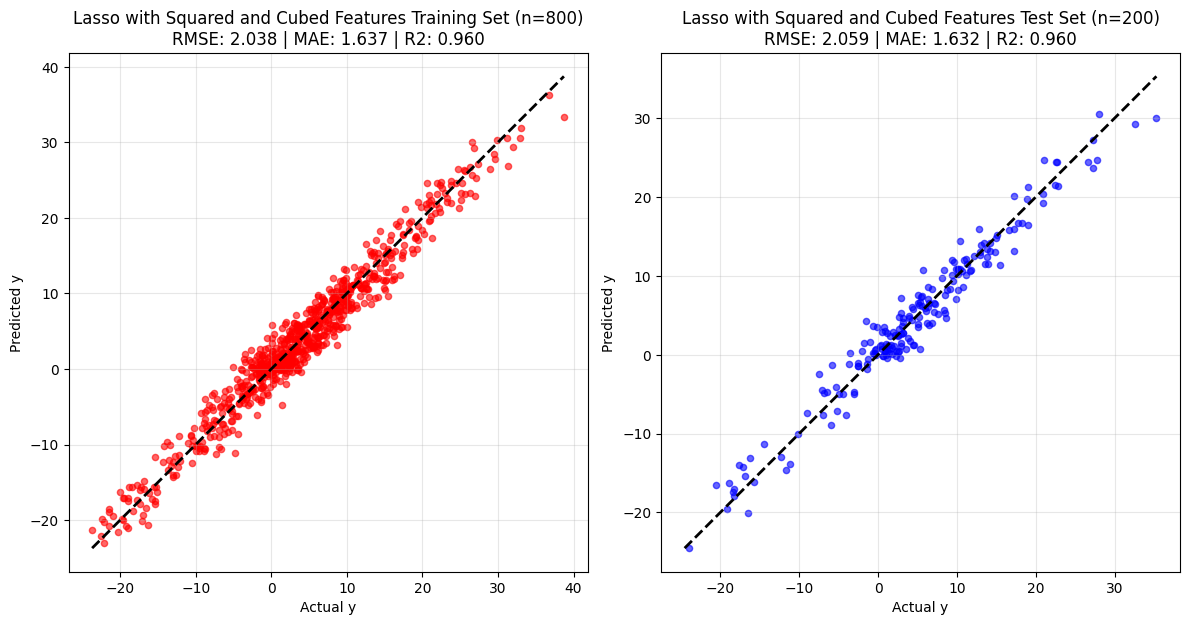

,Feature,Coefficient
11,x4^3,0.904893
4,x1^2,0.364092
0,x1,-0.000000
1,x2,-0.000000
2,x3,0.000000
3,x4,0.000000
5,x1^3,-0.000000
6,x2^2,-0.000000
7,x2^3,-0.000000
8,x3^2,-0.000000


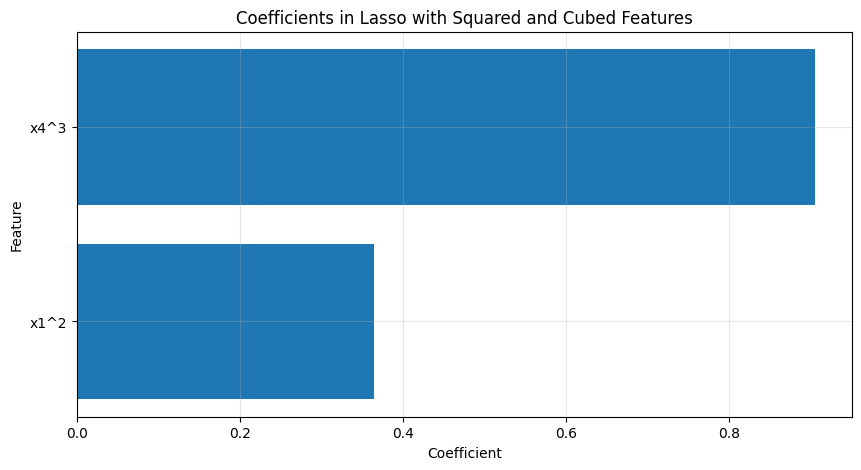

使用された特徴量数: 2 / 12


In [8]:
# Lasso回帰を使って回帰モデルを作る。
# model_name は、評価結果やグラフタイトルに表示する名前。
# ここでは、2乗・3乗特徴量を使ってLasso回帰を行うことが分かる名前にしている。
model_name = 'Lasso with Squared and Cubed Features'

# LassoCV は複数の alpha を試し、交差検証で最も良い alpha を自動的に選ぶ。
# alpha は正則化の強さを表す値。
# alpha が大きいほど、係数を0に近づける力が強くなる。
# alphas=100 は、100個の alpha 候補を自動生成して比較するという意味。
# cv=5 は、学習データを5分割して交差検証するという意味。
# max_iter=100000 は、最適化計算の最大反復回数。
# random_state=42 は、交差検証などで乱数が使われる場合に結果を再現しやすくするための設定。
model = LassoCV(alphas=100, cv=5, max_iter=100000, random_state=42)

# 標準化したトレーニングデータでモデルを学習する。
# 説明変数 auto_X_train と目的変数 auto_y_train は、どちらも標準化済み。
# fit を実行すると、LassoCV が交差検証を行い、最適な alpha と係数を決める。
model.fit(auto_X_train, auto_y_train)

# 選ばれた alpha を表示する。
# この値が大きいほど、より強く特徴量を絞り込むモデルになっている。
print(f'最適な alpha: {model.alpha_:.6f}')

# トレーニングデータに対する予測値を計算し、元のスケールに戻す。
# model.predict は、標準化された目的変数のスケールで予測値を返す。
autoscaled_pred_y_train = model.predict(auto_X_train)
# 標準化を戻す式: 元の値 = 標準化後の値 × 標準偏差 + 平均。
# y_train の平均と標準偏差を使って、予測値を元の目的変数の単位に戻す。
pred_y_train = autoscaled_pred_y_train * y_train.std() + y_train.mean()
# 予測値を DataFrame に変換する。
# index を auto_X_train と合わせることで、元の行番号との対応を保つ。
pred_y_train = pd.DataFrame(pred_y_train, index=auto_X_train.index, columns=['pred_y'])

# テストデータに対する予測値を計算し、元のスケールに戻す。
# テストデータも、学習データと同じ基準で標準化済みの auto_X_test を使って予測する。
autoscaled_pred_y_test = model.predict(auto_X_test)
# テストデータの予測値も、学習データ y_train の平均と標準偏差を使って元のスケールに戻す。
# 学習時に使ったスケールを基準に戻すため、y_test の平均や標準偏差は使わない。
pred_y_test = autoscaled_pred_y_test * y_train.std() + y_train.mean()
# テストデータの予測値を DataFrame に変換する。
# index を X_test と合わせることで、実測値 y_test と対応させやすくする。
pred_y_test = pd.DataFrame(pred_y_test, index=X_test.index, columns=['pred_y'])

# 評価指標とグラフを表示する。
# pred_plot 関数では、学習データとテストデータの RMSE, MAE, R2 と散布図をまとめて表示する。
pred_plot(y_train, pred_y_train, y_test, pred_y_test, model_name, target)

# Lasso回帰で得られた係数を表示する。
# どの特徴量が予測に使われたか、また影響の向きと大きさを確認する。
lasso_coefficients(model, auto_X_train, model_name)


In [9]:
# 予測値の一部を表で確認する。
# 評価指標だけでなく、実際の予測値がどの程度ずれているかを表で見る。
# y_test はテストデータの実測値、pred_y_test はテストデータに対する予測値。
# 同じindexを持つ値を並べることで、各サンプルごとの実測値と予測値を比較できる。
prediction_sample = pd.DataFrame(
    {
        # 実測値の列名には、目的変数名 target を含める。
        f'actual_{target}': y_test,
        # 予測値の列名にも target を含め、何を予測した値か分かるようにする。
        f'predicted_{target}': pred_y_test['pred_y'],
    }
)

# 先頭10行だけ表示する。
# 全件表示すると長くなるため、まずは一部を見て予測結果の雰囲気を確認する。
prediction_sample.head(10)


,actual_y,predicted_y
521,0.536017,0.728857
737,10.184375,8.145622
740,14.151438,13.170673
660,0.240240,1.059068
411,1.811849,0.090938
678,18.973881,16.402328
626,-23.903197,-24.518426
513,14.814199,12.987858
859,18.250924,16.749161
136,0.469196,2.879792
